<a href="https://colab.research.google.com/github/anamaria29/tarea3_compparalela_anam/blob/main/analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio:
## *"NYC Taxi Trip Duration"*

### Librerías:

In [5]:
!pip install polars matplotlib seaborn numpy

In [6]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### Cargar Dataset:

In [7]:
from google.colab import files

uploaded = files.upload()

Saving NYC.csv to NYC.csv


In [8]:
filename = list(uploaded.keys())[0]

df = pl.read_csv(filename)

print("Dataset cargado correctamente")
print("Dimensiones:", df.shape)

df.head()

Dataset cargado correctamente
Dimensiones: (1458644, 11)


id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
str,i64,str,str,i64,f64,f64,f64,f64,str,i64
"""id2875421""",2,"""2016-03-14 17:24:55""","""2016-03-14 17:32:30""",1,-73.982155,40.767937,-73.96463,40.765602,"""N""",455
"""id2377394""",1,"""2016-06-12 00:43:35""","""2016-06-12 00:54:38""",1,-73.980415,40.738564,-73.999481,40.731152,"""N""",663
"""id3858529""",2,"""2016-01-19 11:35:24""","""2016-01-19 12:10:48""",1,-73.979027,40.763939,-74.005333,40.710087,"""N""",2124
"""id3504673""",2,"""2016-04-06 19:32:31""","""2016-04-06 19:39:40""",1,-74.01004,40.719971,-74.012268,40.706718,"""N""",429
"""id2181028""",2,"""2016-03-26 13:30:55""","""2016-03-26 13:38:10""",1,-73.973053,40.793209,-73.972923,40.78252,"""N""",435


### Inspección del Dataset:

Información General:

In [9]:
print("\nColumnas:")
print(df.columns)

print("\nTipos de datos:")
print(df.schema)


Columnas:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']

Tipos de datos:
Schema({'id': String, 'vendor_id': Int64, 'pickup_datetime': String, 'dropoff_datetime': String, 'passenger_count': Int64, 'pickup_longitude': Float64, 'pickup_latitude': Float64, 'dropoff_longitude': Float64, 'dropoff_latitude': Float64, 'store_and_fwd_flag': String, 'trip_duration': Int64})


Tabla de Variables:

In [10]:
variables = pl.DataFrame({
    "Variable": df.columns,
    "Tipo": [
        str(df.schema[col])
        for col in df.columns
    ]
})

variables

Variable,Tipo
str,str
"""id""","""String"""
"""vendor_id""","""Int64"""
"""pickup_datetime""","""String"""
"""dropoff_datetime""","""String"""
"""passenger_count""","""Int64"""
…,…
"""pickup_latitude""","""Float64"""
"""dropoff_longitude""","""Float64"""
"""dropoff_latitude""","""Float64"""


In [11]:
print("Número de registros:", df.shape[0])
print("Número de variables:", df.shape[1])

df.head()

Número de registros: 1458644
Número de variables: 11


id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
str,i64,str,str,i64,f64,f64,f64,f64,str,i64
"""id2875421""",2,"""2016-03-14 17:24:55""","""2016-03-14 17:32:30""",1,-73.982155,40.767937,-73.96463,40.765602,"""N""",455
"""id2377394""",1,"""2016-06-12 00:43:35""","""2016-06-12 00:54:38""",1,-73.980415,40.738564,-73.999481,40.731152,"""N""",663
"""id3858529""",2,"""2016-01-19 11:35:24""","""2016-01-19 12:10:48""",1,-73.979027,40.763939,-74.005333,40.710087,"""N""",2124
"""id3504673""",2,"""2016-04-06 19:32:31""","""2016-04-06 19:39:40""",1,-74.01004,40.719971,-74.012268,40.706718,"""N""",429
"""id2181028""",2,"""2016-03-26 13:30:55""","""2016-03-26 13:38:10""",1,-73.973053,40.793209,-73.972923,40.78252,"""N""",435


Estadísticas Descriptivas:

In [12]:
stats = df.describe()

stats

statistic,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
str,str,f64,str,str,f64,f64,f64,f64,f64,str,f64
"""count""","""1458644""",1.458644e6,"""1458644""","""1458644""",1.458644e6,1.458644e6,1.458644e6,1.458644e6,1.458644e6,"""1458644""",1.458644e6
"""null_count""","""0""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0
"""mean""",null,1.53495,null,null,1.66453,-73.973486,40.750921,-73.973416,40.7518,null,959.492273
"""std""",null,0.498777,null,null,1.314242,0.070902,0.032881,0.070643,0.035891,null,5237.431724
"""min""","""id0000001""",1.0,"""2016-01-01 00:00:17""","""2016-01-01 00:03:31""",0.0,-121.933342,34.359695,-121.933304,32.181141,"""N""",1.0
"""25%""",null,1.0,null,null,1.0,-73.991867,40.737347,-73.991325,40.735886,null,397.0
"""50%""",null,2.0,null,null,1.0,-73.981743,40.754101,-73.979752,40.754524,null,662.0
"""75%""",null,2.0,null,null,2.0,-73.967331,40.76836,-73.963013,40.76981,null,1075.0
"""max""","""id4000000""",2.0,"""2016-06-30 23:59:39""","""2016-07-01 23:02:03""",9.0,-61.335529,51.881084,-61.335529,43.921028,"""Y""",3.526282e6


Estadísticas Numéricas:

In [13]:
numeric = df.select(
    pl.col(
        pl.NUMERIC_DTYPES
    )
)

numeric.describe()

statistic,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
str,f64,f64,f64,f64,f64,f64,f64
"""count""",1.458644e6,1.458644e6,1.458644e6,1.458644e6,1.458644e6,1.458644e6,1.458644e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.53495,1.66453,-73.973486,40.750921,-73.973416,40.7518,959.492273
"""std""",0.498777,1.314242,0.070902,0.032881,0.070643,0.035891,5237.431724
"""min""",1.0,0.0,-121.933342,34.359695,-121.933304,32.181141,1.0
"""25%""",1.0,1.0,-73.991867,40.737347,-73.991325,40.735886,397.0
"""50%""",2.0,1.0,-73.981743,40.754101,-73.979752,40.754524,662.0
"""75%""",2.0,2.0,-73.967331,40.76836,-73.963013,40.76981,1075.0
"""max""",2.0,9.0,-61.335529,51.881084,-61.335529,43.921028,3.526282e6


Valores Faltantes:

In [14]:
missing = df.null_count()

missing

id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0


In [15]:
total = len(df)

missing_summary = []

for col in df.columns:

    nulls = df[col].null_count()

    pct = (
        nulls
        /
        total
    ) * 100

    missing_summary.append([
        col,
        nulls,
        round(
            pct,
            2
        )
    ])

missing_df = pl.DataFrame(
    missing_summary,
    schema=[
        "Variable",
        "Valores faltantes",
        "%"
    ]
)

missing_df.sort(
    "%",
    descending=True
)

Variable,Valores faltantes,%
str,i64,f64
"""id""",0,0.0
"""vendor_id""",0,0.0
"""pickup_datetime""",0,0.0
"""dropoff_datetime""",0,0.0
"""passenger_count""",0,0.0
…,…,…
"""pickup_latitude""",0,0.0
"""dropoff_longitude""",0,0.0
"""dropoff_latitude""",0,0.0


Conversión de Fechas:

In [16]:
df = df.with_columns([

    pl.col(
        "pickup_datetime"
    ).str.to_datetime(),

    pl.col(
        "dropoff_datetime"
    ).str.to_datetime()

])

df.schema

Schema([('id', String),
        ('vendor_id', Int64),
        ('pickup_datetime', Datetime(time_unit='us', time_zone=None)),
        ('dropoff_datetime', Datetime(time_unit='us', time_zone=None)),
        ('passenger_count', Int64),
        ('pickup_longitude', Float64),
        ('pickup_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('store_and_fwd_flag', String),
        ('trip_duration', Int64)])

Variables Temporales:

In [17]:
df = df.with_columns([

    pl.col(
        "pickup_datetime"
    )
    .dt.hour()
    .alias(
        "pickup_hour"
    ),

    pl.col(
        "pickup_datetime"
    )
    .dt.weekday()
    .alias(
        "pickup_day"
    ),

    pl.col(
        "pickup_datetime"
    )
    .dt.month()
    .alias(
        "pickup_month"
    )

])

df.head()

id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month
str,i64,datetime[μs],datetime[μs],i64,f64,f64,f64,f64,str,i64,i8,i8,i8
"""id2875421""",2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.96463,40.765602,"""N""",455,17,1,3
"""id2377394""",1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,"""N""",663,0,7,6
"""id3858529""",2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,"""N""",2124,11,2,1
"""id3504673""",2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.01004,40.719971,-74.012268,40.706718,"""N""",429,19,3,4
"""id2181028""",2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.78252,"""N""",435,13,6,3


Análisis de Variable Objetivo:

In [18]:
target = "trip_duration"

df.select(
    target
).describe()

statistic,trip_duration
str,f64
"""count""",1.458644e6
"""null_count""",0.0
"""mean""",959.492273
"""std""",5237.431724
"""min""",1.0
"""25%""",397.0
"""50%""",662.0
"""75%""",1075.0
"""max""",3.526282e6


Distribución de la Variable Objetivo:

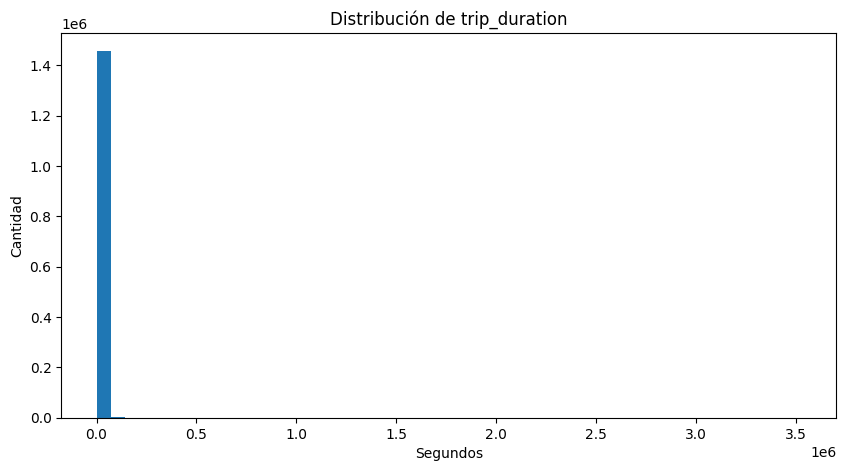

In [19]:
plt.figure(
    figsize=(10,5)
)

plt.hist(
    df[target],
    bins=50
)

plt.title(
    f"Distribución de {target}"
)

plt.xlabel("Segundos")

plt.ylabel("Cantidad")

plt.show()

Escala Log:

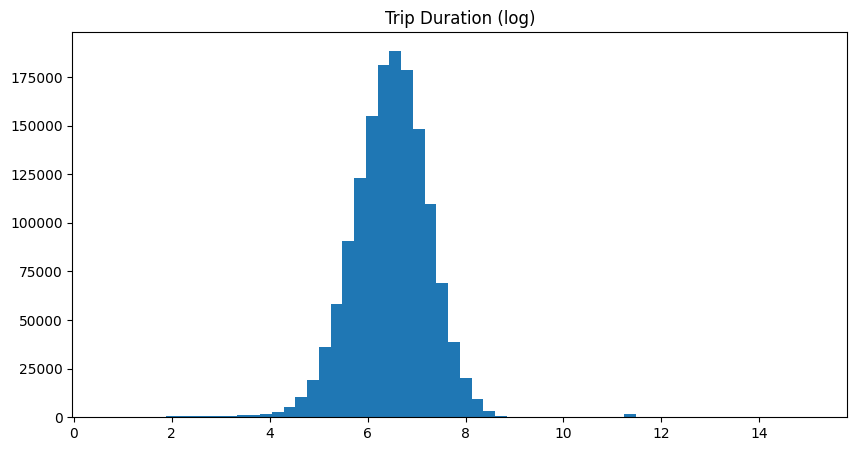

In [20]:
import numpy as np

plt.figure(
    figsize=(10,5)
)

plt.hist(

    np.log1p(
        df["trip_duration"]
    ),

    bins=60

)

plt.title(
    "Trip Duration (log)"
)

plt.show()

Distribución de Variables Numéricas:

In [21]:
numeric_cols = [
    c
    for c
    in df.columns

    if df[c].dtype
    in pl.NUMERIC_DTYPES
]

numeric_cols

['vendor_id',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'trip_duration',
 'pickup_hour',
 'pickup_day',
 'pickup_month']

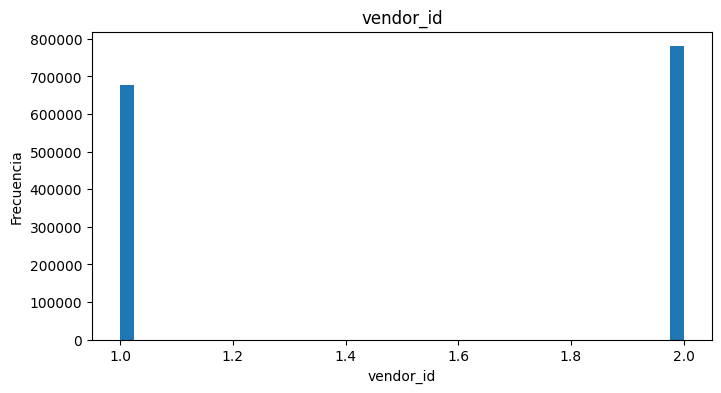

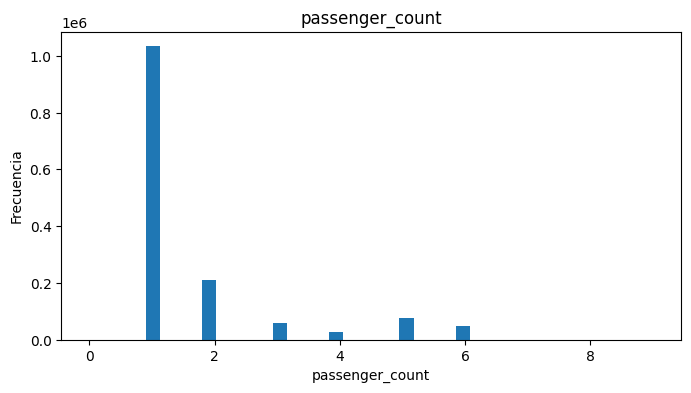

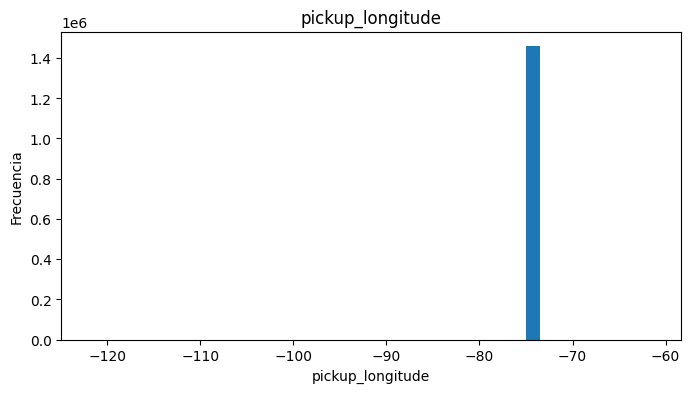

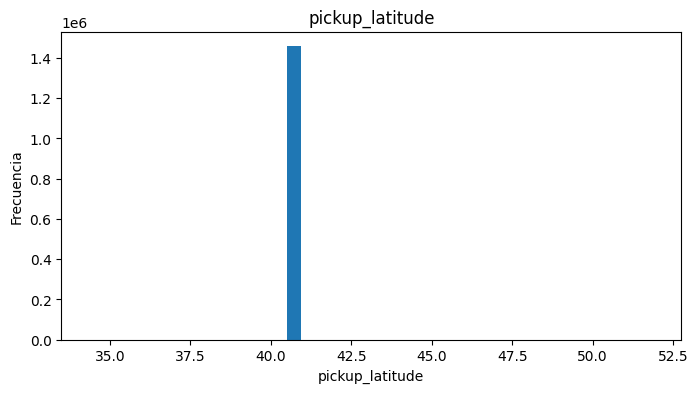

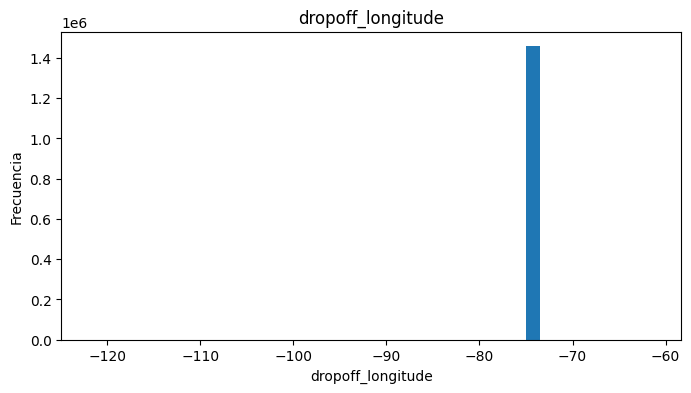

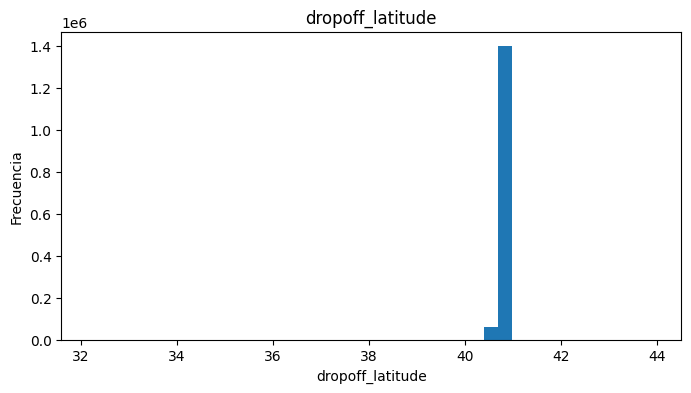

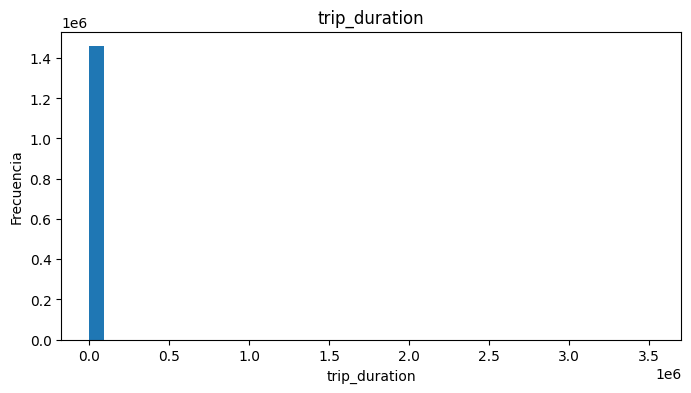

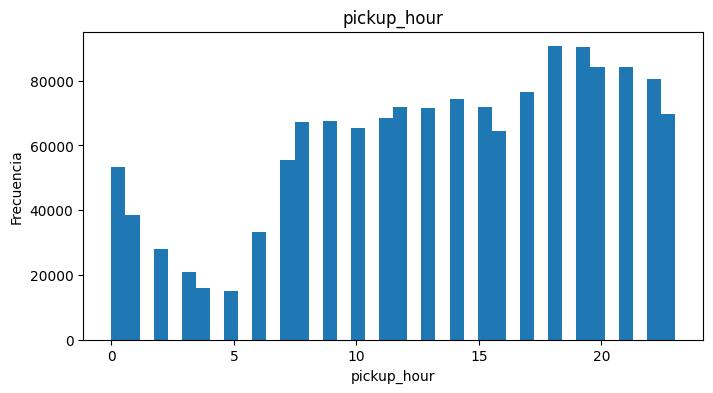

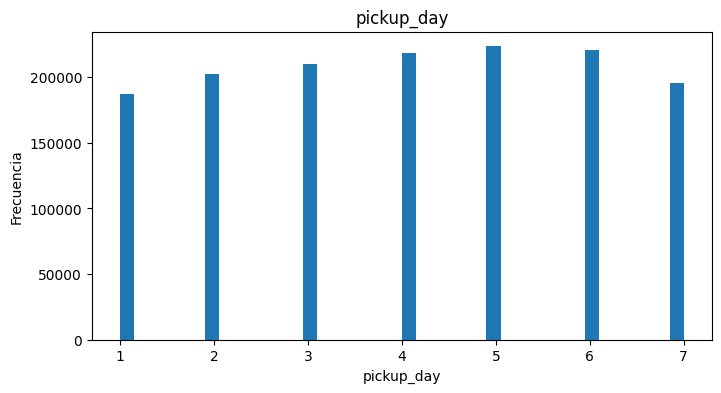

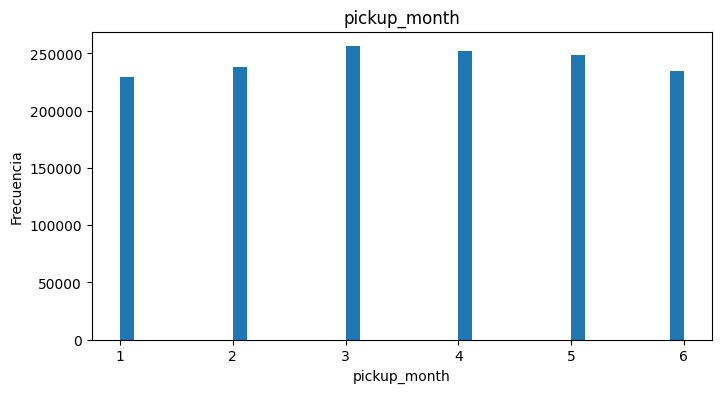

In [22]:
for col in numeric_cols:

    plt.figure(
        figsize=(8,4)
    )

    plt.hist(
        df[col],
        bins=40
    )

    plt.title(
        col
    )

    plt.xlabel(
        col
    )

    plt.ylabel(
        "Frecuencia"
    )

    plt.show()

Distribución de Pasajeros:

In [23]:
passengers = (

df

.group_by(
    "passenger_count"
)

.len()

.sort(
    "passenger_count"
)

)

passengers

passenger_count,len
i64,u32
0,60
1,1033540
2,210318
3,59896
4,28404
5,78088
6,48333
7,3
8,1


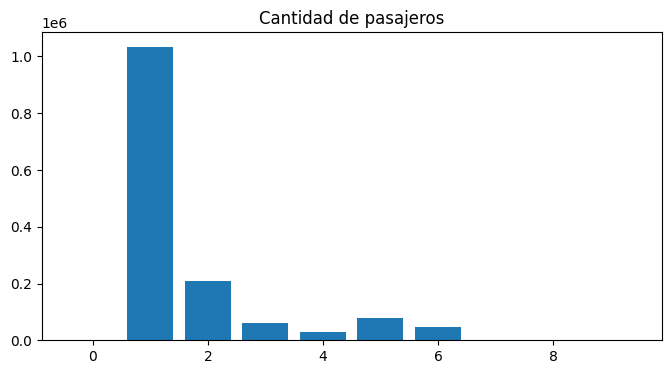

In [24]:
plt.figure(
    figsize=(8,4)
)

plt.bar(
    passengers["passenger_count"],
    passengers["len"]
)

plt.title(
    "Cantidad de pasajeros"
)

plt.show()

Distribución por Hora:

In [25]:
hour_dist = (

df

.group_by(
    "pickup_hour"
)

.len()

.sort(
    "pickup_hour"
)

)

hour_dist

pickup_hour,len
i8,u32
0,53248
1,38571
2,27972
3,20895
4,15792
…,…
19,90308
20,84072
21,84185


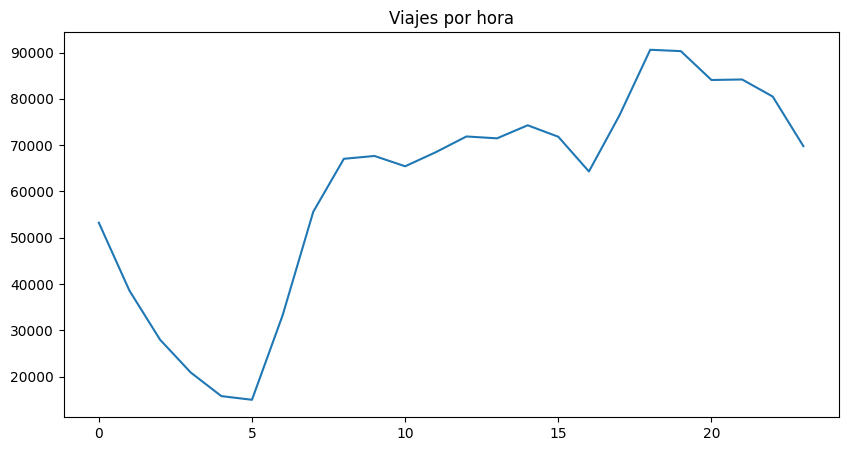

In [26]:
plt.figure(
    figsize=(10,5)
)

plt.plot(
    hour_dist["pickup_hour"],
    hour_dist["len"]
)

plt.title(
    "Viajes por hora"
)

plt.show()

Correlaciones:

In [27]:
numeric = df.select(

[
c

for c

in df.columns

if df[c].dtype

in pl.NUMERIC_DTYPES

]

)

corr = numeric.corr()

corr

vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_hour,pickup_day,pickup_month
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.287415,0.00782,0.001742,0.001528,0.004496,0.020304,0.009299,0.001311,-0.006221
0.287415,1.0,0.002169,-0.005125,-0.000343,-0.002762,0.008471,0.009101,0.025191,-0.002143
0.00782,0.002169,1.0,0.022568,0.783582,0.10019,0.026542,0.01015,-0.016356,0.004474
0.001742,-0.005125,0.022568,1.0,0.114884,0.494038,-0.029204,0.010603,-0.028976,-0.001439
0.001528,-0.000343,0.783582,0.114884,1.0,0.124873,0.014678,-0.022455,-0.00113,0.004758
0.004496,-0.002762,0.10019,0.494038,0.124873,1.0,-0.020677,0.013612,-0.021762,-0.000607
0.020304,0.008471,0.026542,-0.029204,0.014678,-0.020677,1.0,0.00369,-0.000708,0.006607
0.009299,0.009101,0.01015,0.010603,-0.022455,0.013612,0.00369,1.0,-0.084255,-0.003438
0.001311,0.025191,-0.016356,-0.028976,-0.00113,-0.021762,-0.000708,-0.084255,1.0,-0.014544


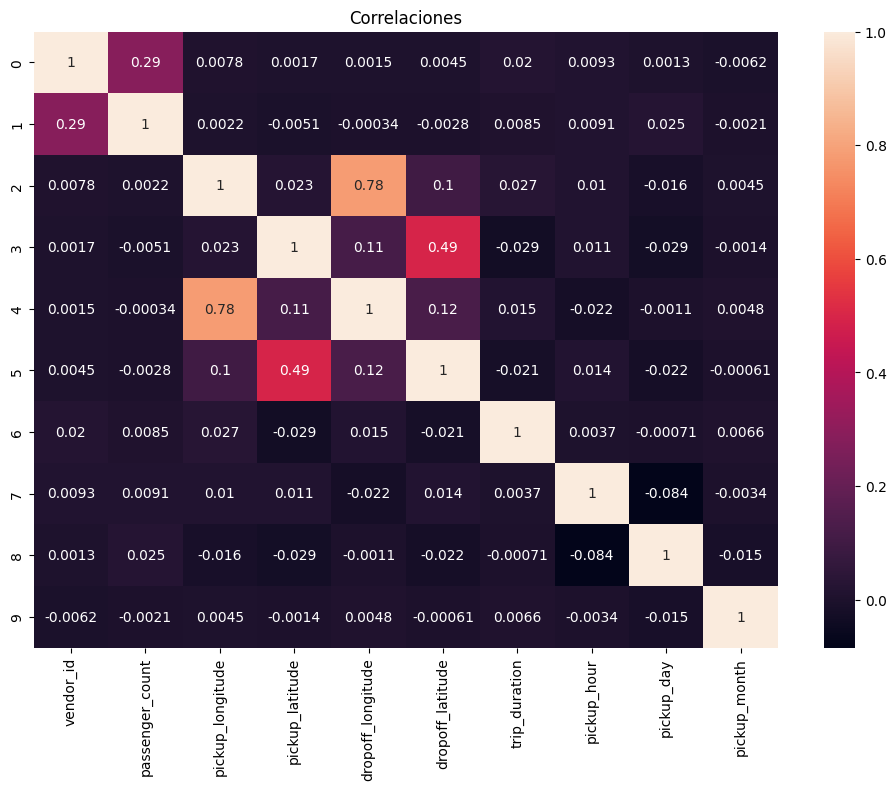

In [28]:
plt.figure(
    figsize=(12,8)
)

sns.heatmap(

corr.to_pandas(),

annot=True

)

plt.title(
    "Correlaciones"
)

plt.show()

Outliers:

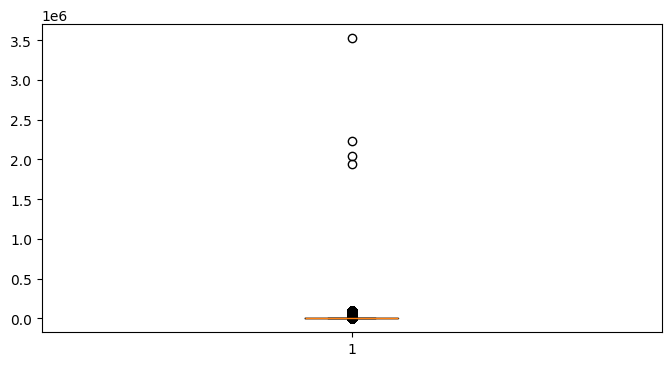

In [29]:
plt.figure(
    figsize=(8,4)
)

plt.boxplot(
    df["trip_duration"]
)

plt.show()

Análisis Adicionales:

In [30]:
(
df

.group_by(
"store_and_fwd_flag"
)

.len()

)

store_and_fwd_flag,len
str,u32
"""N""",1450599
"""Y""",8045


In [31]:
(
df

.group_by(
"passenger_count"
)

.len()

.sort(
"passenger_count"
)

)

passenger_count,len
i64,u32
0,60
1,1033540
2,210318
3,59896
4,28404
5,78088
6,48333
7,3
8,1


# Carga de Archivos:

## Feature Engineering:

In [37]:
from google.colab import files

uploaded = files.upload()

Saving feature_engineering.py to feature_engineering (2).py


In [38]:
import sys

sys.path.append(
    "."
)

In [39]:
from feature_engineering import engineer_features

In [40]:
df_ml = engineer_features(df)

print(df_ml.shape)

df_ml.head()

(1435455, 16)


id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,trip_distance,vendor_avg_duration
str,i64,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,i32,i64,i8,i8,i8,f64,f64
"""id2875421""",2,2016-03-14 17:24:55,2016-03-14 17:32:30,1.0,-73.982155,40.767937,-73.96463,40.765602,0,455,17,1,3,0.01768,815.048345
"""id2377394""",1,2016-06-12 00:43:35,2016-06-12 00:54:38,1.0,-73.980415,40.738564,-73.999481,40.731152,0,663,0,7,6,0.020456,808.834333
"""id3858529""",2,2016-01-19 11:35:24,2016-01-19 12:10:48,1.0,-73.979027,40.763939,-74.005333,40.710087,0,2124,11,2,1,0.059934,815.048345
"""id3504673""",2,2016-04-06 19:32:31,2016-04-06 19:39:40,1.0,-74.01004,40.719971,-74.012268,40.706718,0,429,19,3,4,0.013438,815.048345
"""id2181028""",2,2016-03-26 13:30:55,2016-03-26 13:38:10,1.0,-73.973053,40.793209,-73.972923,40.78252,0,435,13,6,3,0.01069,815.048345


Guardar Datos:

In [42]:
df_ml.write_parquet(
"processed_taxi.parquet"
)

print(
    "Archivo generado"
)

Archivo generado


In [43]:
from google.colab import files

files.download(
    "processed_taxi.parquet"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Preprocessing:

In [44]:
from google.colab import files

files.upload()

Saving preprocessing.py to preprocessing.py


{'preprocessing.py': b'import polars as pl\n\nfrom sklearn.model_selection import train_test_split\n\n\ndef preprocess_data(df):\n\n    df_ml = df.clone()\n\n    # ELIMINAR COLUMNAS\n\n    drop_cols = [\n\n        "id",\n\n        "pickup_datetime",\n\n        "dropoff_datetime"\n\n    ]\n\n    df_ml = (\n\n        df_ml\n\n        .drop(\n            drop_cols\n        )\n\n    )\n\n    # TARGET\n\n    target = (\n\n        "trip_duration"\n\n    )\n\n    X = (\n\n        df_ml\n\n        .drop(\n            target\n        )\n\n    )\n\n    y = (\n\n        df_ml\n\n        .select(\n            target\n        )\n\n        .to_numpy()\n\n        .ravel()\n\n    )\n\n    # A NUMPY\n\n    X = (\n\n        X\n\n        .to_numpy()\n\n    )\n\n    # SPLIT\n\n    (\n\n        X_train,\n\n        X_test,\n\n        y_train,\n\n        y_test\n\n    ) = (\n\n        train_test_split(\n\n            X,\n\n            y,\n\n            test_size=0.2,\n\n            random_state=42\n\n       

In [45]:
from preprocessing import preprocess_data

In [46]:
X_train,X_test,y_train,y_test = preprocess_data(df_ml)

print(X_train.shape)

print(X_test.shape)

(1148364, 12)
(287091, 12)


## Entrenamiento de Modelos:

In [47]:
from google.colab import files

files.upload()

Saving train_models.py to train_models.py


{'train_models.py': b'import time\n\nimport pandas as pd\n\nfrom sklearn.linear_model import LinearRegression\n\nfrom sklearn.ensemble import (\n    RandomForestRegressor,\n    GradientBoostingRegressor\n)\n\nfrom sklearn.metrics import (\n    mean_absolute_error,\n    root_mean_squared_error\n)\n\n\ndef train_models(\n\n    X_train,\n    X_test,\n    y_train,\n    y_test\n\n):\n\n    models = {\n\n        "Linear Regression":\n\n            LinearRegression(),\n\n        "Random Forest":\n\n            RandomForestRegressor(\n\n                n_estimators=50,\n                random_state=42,\n                n_jobs=-1\n\n            ),\n\n        "Gradient Boosting":\n\n            GradientBoostingRegressor(\n\n                random_state=42\n\n            )\n\n    }\n\n    results = []\n\n    for name, model in models.items():\n\n        start = time.time()\n\n        model.fit(\n\n            X_train,\n\n            y_train\n\n        )\n\n        train_time = (\n\n            ti

In [48]:
from train_models import train_models

In [49]:
results = train_models(

    X_train,
    X_test,

    y_train,
    y_test

)

results

,Model,Training Time,RMSE,MAE
0,Linear Regression,0.605258,432.365751,287.958390
1,Random Forest,788.748399,258.487529,175.567753
2,Gradient Boosting,448.464492,299.190959,209.035508


## Polars Pipeline:

In [50]:
from google.colab import files

files.upload()

Saving polars_pipeline.py to polars_pipeline.py


{'polars_pipeline.py': b'import time\nimport polars as pl\n\nfrom feature_engineering import (\n    engineer_features\n)\n\n\ndef run_polars_pipeline(path):\n\n    results = {}\n\n    total_start = time.time()\n\n    # LECTURA\n\n    start = time.time()\n\n    df = pl.read_csv(path)\n\n    df = df.with_columns([\n\n        pl.col(\n            "pickup_datetime"\n        )\n        .str.to_datetime(),\n\n        pl.col(\n            "dropoff_datetime"\n        )\n        .str.to_datetime()\n\n    ])\n\n    results["read_time"] = (\n\n        time.time()\n\n        -\n\n        start\n\n    )\n\n    # FEATURE ENGINEERING\n\n    start = time.time()\n\n    df_ml = engineer_features(df)\n\n    results["feature_time"] = (\n\n        time.time()\n\n        -\n\n        start\n\n    )\n\n    # FILTRADO\n\n    start = time.time()\n\n    filtered = (\n\n        df_ml\n\n        .filter(\n\n            pl.col(\n                "trip_duration"\n            )\n\n            > 300\n\n        )\n\n  

In [51]:
from polars_pipeline import (
    run_polars_pipeline
)

In [52]:
results_polars = (

run_polars_pipeline(

filename

)

)

results_polars

{'read_time': 2.2247443199157715,
 'feature_time': 0.7644879817962646,
 'filter_time': 0.04648232460021973,
 'aggregation_time': 0.013717412948608398,
 'join_time': 0.0650641918182373,
 'total_time': 3.1145169734954834}

## Pandas Pipeline:

In [53]:
from google.colab import files

files.upload()

Saving pandas_pipeline.py to pandas_pipeline.py


{'pandas_pipeline.py': b'import time\n\nimport pandas as pd\n\nimport numpy as np\n\n\ndef run_pandas_pipeline(path):\n\n    results = {}\n\n    total_start = time.time()\n\n    # LECTURA\n\n    start = time.time()\n\n    df = pd.read_csv(path)\n\n    df["pickup_datetime"] = pd.to_datetime(\n        df["pickup_datetime"]\n    )\n\n    df["dropoff_datetime"] = pd.to_datetime(\n        df["dropoff_datetime"]\n    )\n\n    results["read_time"] = (\n\n        time.time()\n\n        -\n\n        start\n\n    )\n\n    # FEATURE ENGINEERING\n\n    start = time.time()\n\n    upper = (\n\n        df[\n            "trip_duration"\n        ]\n\n        .quantile(\n            0.99\n        )\n\n    )\n\n    df = df[\n\n        (\n            df[\n                "trip_duration"\n            ]\n\n            >= 60\n\n        )\n\n        &\n\n        (\n            df[\n                "trip_duration"\n            ]\n\n            <= upper\n\n        )\n\n        &\n\n        (\n            df[\n 

In [54]:
from pandas_pipeline import (
    run_pandas_pipeline
)

In [55]:
results_pandas = (

run_pandas_pipeline(

filename

)

)

results_pandas

{'read_time': 8.098047018051147,
 'feature_time': 0.47104907035827637,
 'filter_time': 0.11836838722229004,
 'aggregation_time': 0.032079219818115234,
 'join_time': 0.3804311752319336,
 'total_time': 9.099988222122192}

## Comparación:

Speedup:

In [56]:
import pandas as pd

comparison = pd.DataFrame({

"Operation":[
"Read",
"Feature Engineering",
"Filter",
"Aggregation",
"Join",
"Total"
],

"Polars":[
results_polars["read_time"],
results_polars["feature_time"],
results_polars["filter_time"],
results_polars["aggregation_time"],
results_polars["join_time"],
results_polars["total_time"]
],

"Pandas":[
results_pandas["read_time"],
results_pandas["feature_time"],
results_pandas["filter_time"],
results_pandas["aggregation_time"],
results_pandas["join_time"],
results_pandas["total_time"]
]

})

comparison["Speedup"] = (

comparison["Pandas"]

/

comparison["Polars"]

)

comparison

,Operation,Polars,Pandas,Speedup
0,Read,2.224744,8.098047,3.639990
1,Feature Engineering,0.764488,0.471049,0.616163
2,Filter,0.046482,0.118368,2.546525
3,Aggregation,0.013717,0.032079,2.338577
4,Join,0.065064,0.380431,5.847013
5,Total,3.114517,9.099988,2.921798


Escalabilidad:

In [57]:
import polars as pl

sizes = {

"25":0.25,

"50":0.50,

"75":0.75,

"100":1.00

}

datasets = {}

for name, frac in sizes.items():

    datasets[name] = (

        df.sample(

            fraction=frac,

            seed=42

        )

    )

print(
    "Subconjuntos creados"
)

Subconjuntos creados


In [58]:
paths = {}

for name, data in datasets.items():

    path = (

        f"subset_{name}.csv"

    )

    data.write_csv(
        path
    )

    paths[name] = path

print(
    paths
)

{'25': 'subset_25.csv', '50': 'subset_50.csv', '75': 'subset_75.csv', '100': 'subset_100.csv'}


In [59]:
import pandas as pd

rows = []

for size,path in paths.items():

    polars = (

        run_polars_pipeline(
            path
        )

    )

    pandas = (

        run_pandas_pipeline(
            path
        )

    )

    rows.append([

        size,

        polars["total_time"],

        pandas["total_time"],

        pandas["total_time"]

        /

        polars["total_time"]

    ])

scaling = pd.DataFrame(

rows,

columns=[

"Dataset",

"Polars",

"Pandas",

"Speedup"

]

)

scaling

,Dataset,Polars,Pandas,Speedup
0,25,1.636317,2.038754,1.245940
1,50,1.610624,4.950681,3.073767
2,75,2.519825,7.175310,2.847543
3,100,3.093792,8.730627,2.821983


Gráfico:

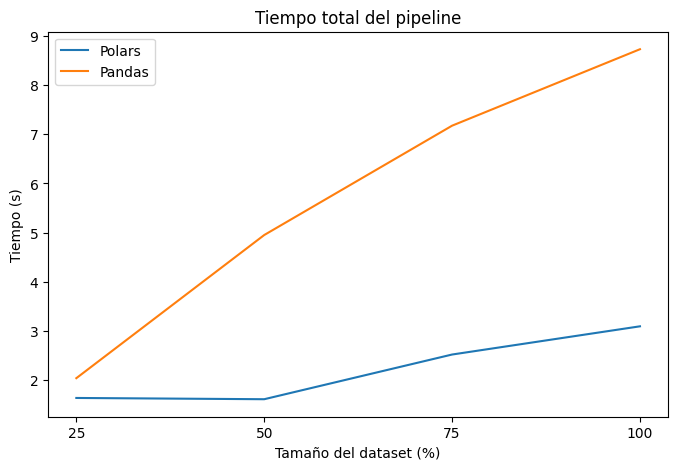

In [60]:
import matplotlib.pyplot as plt

plt.figure(
figsize=(8,5)
)

plt.plot(

scaling["Dataset"],

scaling["Polars"]

)

plt.plot(

scaling["Dataset"],

scaling["Pandas"]

)

plt.title(
"Tiempo total del pipeline"
)

plt.xlabel(
"Tamaño del dataset (%)"
)

plt.ylabel(
"Tiempo (s)"
)

plt.legend([

"Polars",

"Pandas"

])

plt.show()

## Lazy Execution:

In [61]:
import time
import polars as pl

# read_csv

start = time.time()

df_read = pl.read_csv(
    filename
)

read_time = (

    time.time()

    -

    start

)

# scan_csv

start = time.time()

df_lazy = (

    pl

    .scan_csv(
        filename
    )

    .collect()

)

lazy_time = (

    time.time()

    -

    start

)

print(
    "read_csv:",
    read_time
)

print(
    "scan_csv:",
    lazy_time
)

read_csv: 0.7807154655456543
scan_csv: 0.8496196269989014


In [62]:
import psutil

ram_total = (

    psutil

    .virtual_memory()

    .total

    /

    1024**3

)

ram_available = (

    psutil

    .virtual_memory()

    .available

    /

    1024**3

)

print(
    "RAM total:",
    round(
        ram_total,
        2
    ),
    "GB"
)

print(
    "RAM disponible:",
    round(
        ram_available,
        2
    ),
    "GB"
)

RAM total: 12.67 GB
RAM disponible: 10.07 GB


In [63]:
import os

cores = os.cpu_count()

print(
    "CPU cores:",
    cores
)

CPU cores: 2
